# 问题三逆向验证（二）：公式分项特征 + RF / XGBoost

参考 `p3_inv.ipynb` 的物料衡算思路：

$$
C_{t+1}=\underbrace{C_t}_{\text{当前状态}}+
\underbrace{\frac{\Delta t\,Q_{in,t}C_{in,t}}{V_t}}_{\text{入流项}}-
\underbrace{\frac{\Delta t\,Q_{out,t}C_t}{V_t}}_{\text{出流项}}
$$

本 notebook 不再把入流项与出流项预先合并成净负荷，而是将公式中的三项分别作为特征，交给随机森林（RF）和 XGBoost 拟合下一时刻 `NTU`。同时考察：

1. 每个分项与下一时刻 `NTU`、下一时刻变化量 $\Delta NTU$ 的相关性；
2. 模型预测值与真实值的 Pearson / Spearman 相关性及误差；
3. 模型对变化量的拟合能力，避免当前 `NTU` 的强自相关掩盖动态项效果；
4. 各分项的置换重要性。

> `C/W WELL LEVEL` 仍只是相对体积代理。分别测试 `R/W FLOW` 和 `T/W FLOW` 作为 $Q_{in}$ 的两种方案。

## 1. 导入依赖与读取数据

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

candidates = [Path("merged.xlsx"), Path("../data/merged.xlsx"), Path("data/merged.xlsx")]
data_path = next((p for p in candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("未找到 merged.xlsx，请从 codes 目录或项目根目录运行本 notebook。")

df = pd.read_excel(data_path, sheet_name="Merged")
df["DATETIME"] = pd.to_datetime(df["DATE"].astype(str) + " " + df["TIME"].astype(str))
df = df.sort_values("DATETIME").reset_index(drop=True)

print(f"数据文件：{data_path.resolve()}")
print(f"记录数：{len(df):,}")
print(f"时间范围：{df['DATETIME'].min()} 至 {df['DATETIME'].max()}")

数据文件：/Users/jinyu/workspace/2026亚太杯/data/merged.xlsx
记录数：5,460
时间范围：2025-01-01 07:00:00 至 2026-04-01 05:00:00


## 2. 将公式逐项拆成特征

所有特征只使用时刻 $t$ 可获得的信息，目标为 $C_{t+1}$。出流项保存为正值，公式中的负号由模型自行学习。

- `current_NTU`：$C_t$
- `inflow_RW`：$\Delta t\,Q_{in,t}C_{in,t}/V_t$，其中 $Q_{in}=R/W FLOW$
- `inflow_TW`：同上，其中 $Q_{in}=T/W FLOW$
- `outflow`：$\Delta t\,Q_{out,t}C_t/V_t$

In [2]:
DT_HOURS = 2
required = ["NTU", "FILT. NTU", "C/W WELL LEVEL", "R/W FLOW", "T/W FLOW"]

interval_hours = df["DATETIME"].diff().dt.total_seconds().div(3600)
assert interval_hours.dropna().eq(DT_HOURS).all(), "数据并非严格 2 小时间隔，需要先重新采样。"

level = df["C/W WELL LEVEL"].replace(0, np.nan)
df["current_NTU"] = df["NTU"]
df["inflow_RW"] = DT_HOURS * df["R/W FLOW"] * df["FILT. NTU"] / level
df["inflow_TW"] = DT_HOURS * df["T/W FLOW"] * df["FILT. NTU"] / level
df["outflow"] = DT_HOURS * df["T/W FLOW"] * df["NTU"] / level
df["next_NTU"] = df["NTU"].shift(-1)
df["delta_NTU_next"] = df["next_NTU"] - df["current_NTU"]

feature_sets = {
    "RW as Qin": ["current_NTU", "inflow_RW", "outflow"],
    "TW as Qin": ["current_NTU", "inflow_TW", "outflow"],
}

quality = pd.DataFrame({
    "非缺失数": df[required].notna().sum(),
    "缺失率": df[required].isna().mean(),
    "最小值": df[required].min(),
    "中位数": df[required].median(),
    "最大值": df[required].max(),
})
display(quality.style.format({"缺失率": "{:.2%}", "最小值": "{:.4f}", "中位数": "{:.4f}", "最大值": "{:.4f}"}))
display(df[["DATETIME", "current_NTU", "inflow_RW", "inflow_TW", "outflow", "next_NTU", "delta_NTU_next"]].head())

,非缺失数,缺失率,最小值,中位数,最大值
NTU,5124,6.15%,0.0800,0.3100,11.9000
FILT. NTU,5460,0.00%,0.0200,0.0600,9.8000
C/W WELL LEVEL,5460,0.00%,1.3400,3.8000,3.9800
R/W FLOW,5460,0.00%,4.7000,49.5000,63.4000
T/W FLOW,5460,0.00%,17.5000,45.5000,55.6000


,DATETIME,current_NTU,inflow_RW,inflow_TW,outflow,next_NTU,delta_NTU_next
0,2025-01-01 07:00:00,0.12,0.948691,0.892147,2.676440,0.12,0.00
1,2025-01-01 09:00:00,0.12,1.186352,1.118110,2.683465,0.12,0.00
2,2025-01-01 11:00:00,0.12,1.178478,1.120735,2.689764,0.11,-0.01
3,2025-01-01 13:00:00,0.11,1.254190,1.181564,2.599441,0.11,0.00
4,2025-01-01 15:00:00,0.11,1.243017,1.187151,2.611732,0.11,0.00


## 3. 单项相关性

`next_NTU` 相关性反映对绝对浊度的解释力；`delta_NTU_next` 相关性更严格地反映对未来变化方向和幅度的解释力。

In [3]:
def safe_corr(a, b, method="pearson"):
    pair = pd.DataFrame({"a": np.asarray(a, dtype=float), "b": np.asarray(b, dtype=float)}).dropna()
    if len(pair) < 3 or pair["a"].nunique() < 2 or pair["b"].nunique() < 2:
        return np.nan
    fn = pearsonr if method == "pearson" else spearmanr
    return fn(pair["a"], pair["b"]).statistic

term_labels = {
    "current_NTU": "Current state Ct",
    "inflow_RW": "Inflow term (RW as Qin)",
    "inflow_TW": "Inflow term (TW as Qin)",
    "outflow": "Outflow term",
}
corr_rows = []
for col, label in term_labels.items():
    corr_rows.append({
        "公式分项": label,
        "与 next_NTU 的 Pearson r": safe_corr(df[col], df["next_NTU"]),
        "与 next_NTU 的 Spearman ρ": safe_corr(df[col], df["next_NTU"], "spearman"),
        "与 ΔNTU 的 Pearson r": safe_corr(df[col], df["delta_NTU_next"]),
        "与 ΔNTU 的 Spearman ρ": safe_corr(df[col], df["delta_NTU_next"], "spearman"),
    })

corr_table = pd.DataFrame(corr_rows)
display(corr_table.style.format({col: "{:.4f}" for col in corr_table.columns if col != "公式分项"}))

,公式分项,与 next_NTU 的 Pearson r,与 next_NTU 的 Spearman ρ,与 ΔNTU 的 Pearson r,与 ΔNTU 的 Spearman ρ
0,Current state Ct,0.8814,0.9699,-0.2435,-0.0945
1,Inflow term (RW as Qin),0.6695,0.2723,-0.0605,0.0204
2,Inflow term (TW as Qin),0.6692,0.2653,-0.0592,0.0231
3,Outflow term,0.8711,0.9633,-0.2484,-0.0958


## 4. 时间顺序训练 RF 与 XGBoost

前 80% 样本训练，后 20% 样本测试，不随机打乱。由于物料衡算公式直接描述增量，模型拟合 `delta_NTU_next`，再通过 `current_NTU + 预测变化量` 还原 `next_NTU`。持久性基线令预测变化量为 0，即 $\hat C_{t+1}=C_t$。

In [4]:
models = {
    "RF": lambda: RandomForestRegressor(
        n_estimators=500, min_samples_leaf=3, max_features=1.0,
        random_state=42, n_jobs=-1
    ),
    "XGBoost": lambda: XGBRegressor(
        n_estimators=500, learning_rate=0.03, max_depth=4,
        min_child_weight=5, subsample=0.8, colsample_bytree=0.9,
        objective="reg:squarederror", random_state=42, n_jobs=-1
    ),
}

def metric_row(scenario, model_name, y_true, y_pred, current_ntu):
    true_delta = np.asarray(y_true) - np.asarray(current_ntu)
    pred_delta = np.asarray(y_pred) - np.asarray(current_ntu)
    nonzero = true_delta != 0
    return {
        "Qin 方案": scenario,
        "模型": model_name,
        "测试样本数": len(y_true),
        "next_NTU Pearson r": safe_corr(y_true, y_pred),
        "next_NTU Spearman ρ": safe_corr(y_true, y_pred, "spearman"),
        "R²": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "ΔNTU Pearson r": safe_corr(true_delta, pred_delta),
        "ΔNTU Spearman ρ": safe_corr(true_delta, pred_delta, "spearman"),
        "非零变化方向准确率": np.mean(np.sign(true_delta[nonzero]) == np.sign(pred_delta[nonzero])),
    }

metric_rows = []
importance_rows = []
predictions = {}
fitted_models = {}

for scenario, features in feature_sets.items():
    data = df[["DATETIME", "next_NTU", "delta_NTU_next"] + features].replace([np.inf, -np.inf], np.nan).dropna().copy()
    split = int(len(data) * 0.8)
    train, test = data.iloc[:split], data.iloc[split:]
    X_train, y_train_delta = train[features], train["delta_NTU_next"]
    X_test, y_test = test[features], test["next_NTU"]
    y_test_delta = test["delta_NTU_next"]

    baseline_pred = X_test["current_NTU"].to_numpy()
    metric_rows.append(metric_row(scenario, "持久性基线", y_test, baseline_pred, X_test["current_NTU"]))

    for model_name, factory in models.items():
        model = factory()
        model.fit(X_train, y_train_delta)
        pred_delta = model.predict(X_test)
        pred = X_test["current_NTU"].to_numpy() + pred_delta
        metric_rows.append(metric_row(scenario, model_name, y_test, pred, X_test["current_NTU"]))

        perm = permutation_importance(
            model, X_test, y_test_delta, n_repeats=10,
            scoring="neg_mean_squared_error", random_state=42, n_jobs=-1
        )
        for feature, mean, std in zip(features, perm.importances_mean, perm.importances_std):
            importance_rows.append({
                "Qin 方案": scenario, "模型": model_name, "特征": term_labels.get(feature, feature),
                "置换重要性（MSE 增量）": mean, "标准差": std,
            })

        key = (scenario, model_name)
        predictions[key] = pd.DataFrame({
            "DATETIME": test["DATETIME"].to_numpy(),
            "Observed next_NTU": y_test.to_numpy(),
            "Predicted next_NTU": pred,
            "current_NTU": X_test["current_NTU"].to_numpy(),
        })
        fitted_models[key] = model

metrics = pd.DataFrame(metric_rows)
importance_table = pd.DataFrame(importance_rows)
metric_format = {col: "{:.4f}" for col in metrics.columns if col not in ["Qin 方案", "模型", "测试样本数"]}
display(metrics.style.format(metric_format))

,Qin 方案,模型,测试样本数,next_NTU Pearson r,next_NTU Spearman ρ,R²,RMSE,MAE,ΔNTU Pearson r,ΔNTU Spearman ρ,非零变化方向准确率
0,RW as Qin,持久性基线,1025,0.9175,0.9698,0.8350,0.1136,0.0361,nan,nan,0.0000
1,RW as Qin,RF,1025,0.8070,0.9513,0.4497,0.2075,0.0572,0.3310,0.1116,0.5376
2,RW as Qin,XGBoost,1025,0.8814,0.9661,0.7217,0.1476,0.0483,0.3259,0.1181,0.5414
3,TW as Qin,持久性基线,1025,0.9175,0.9698,0.8350,0.1136,0.0361,nan,nan,0.0000
4,TW as Qin,RF,1025,0.8277,0.9581,0.5457,0.1885,0.0545,0.3408,0.1066,0.5376
5,TW as Qin,XGBoost,1025,0.8888,0.9671,0.7557,0.1382,0.0461,0.3187,0.1169,0.5489


## 5. 分项置换重要性

置换某特征后测试集 MSE 增加越多，说明模型越依赖该特征；接近 0 或为负表示该特征在测试期几乎没有稳定增益。

,Qin 方案,模型,特征,置换重要性（MSE 增量）,标准差
1,RW as Qin,RF,Inflow term (RW as Qin),0.077931,0.004302
2,RW as Qin,RF,Outflow term,0.030002,0.002583
0,RW as Qin,RF,Current state Ct,0.019860,0.002191
3,RW as Qin,XGBoost,Current state Ct,0.027679,0.002167
4,RW as Qin,XGBoost,Inflow term (RW as Qin),0.026238,0.001808
5,RW as Qin,XGBoost,Outflow term,0.001000,0.000986
7,TW as Qin,RF,Inflow term (TW as Qin),0.070196,0.003669
8,TW as Qin,RF,Outflow term,0.033508,0.002241
6,TW as Qin,RF,Current state Ct,0.015305,0.001178
9,TW as Qin,XGBoost,Current state Ct,0.031674,0.002164


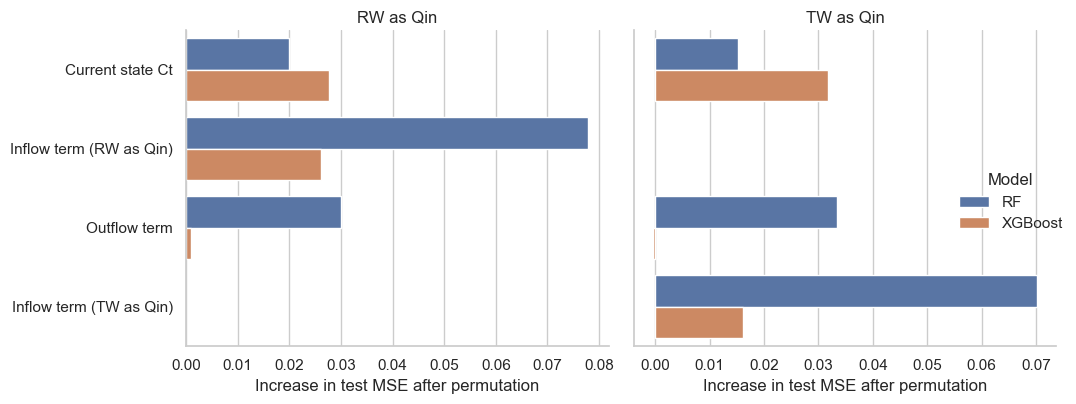

In [5]:
display(importance_table.sort_values(["Qin 方案", "模型", "置换重要性（MSE 增量）"], ascending=[True, True, False]).style.format({
    "置换重要性（MSE 增量）": "{:.6f}", "标准差": "{:.6f}"
}))

g = sns.catplot(
    data=importance_table, kind="bar", x="置换重要性（MSE 增量）", y="特征",
    hue="模型", col="Qin 方案", height=4.2, aspect=1.15, sharex=False
)
g.set_titles("{col_name}")
g.set_axis_labels("Increase in test MSE after permutation", "")
if g._legend is not None:
    g._legend.set_title("Model")
plt.tight_layout()
plt.show()

## 6. 测试期预测可视化

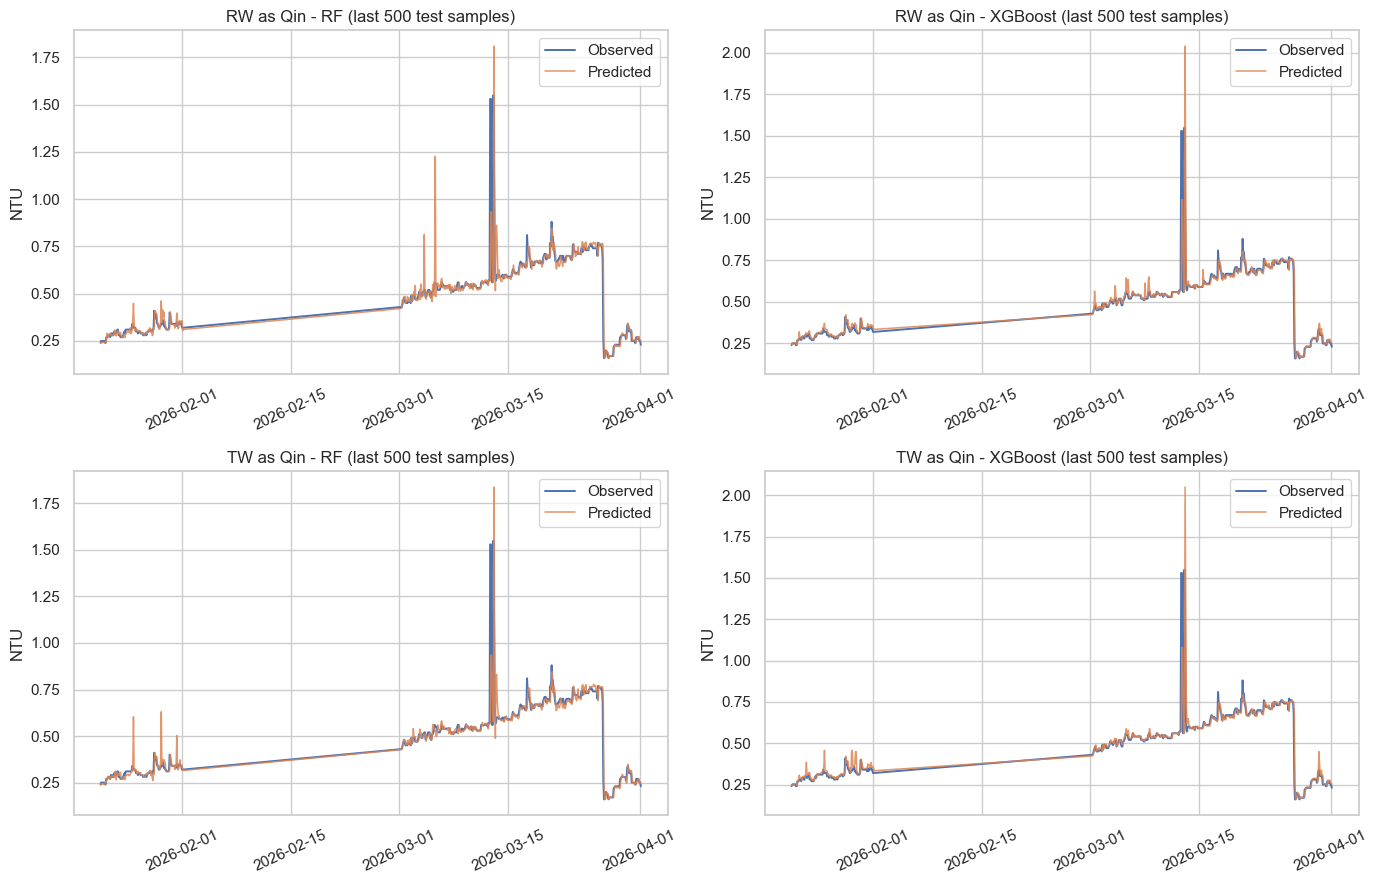

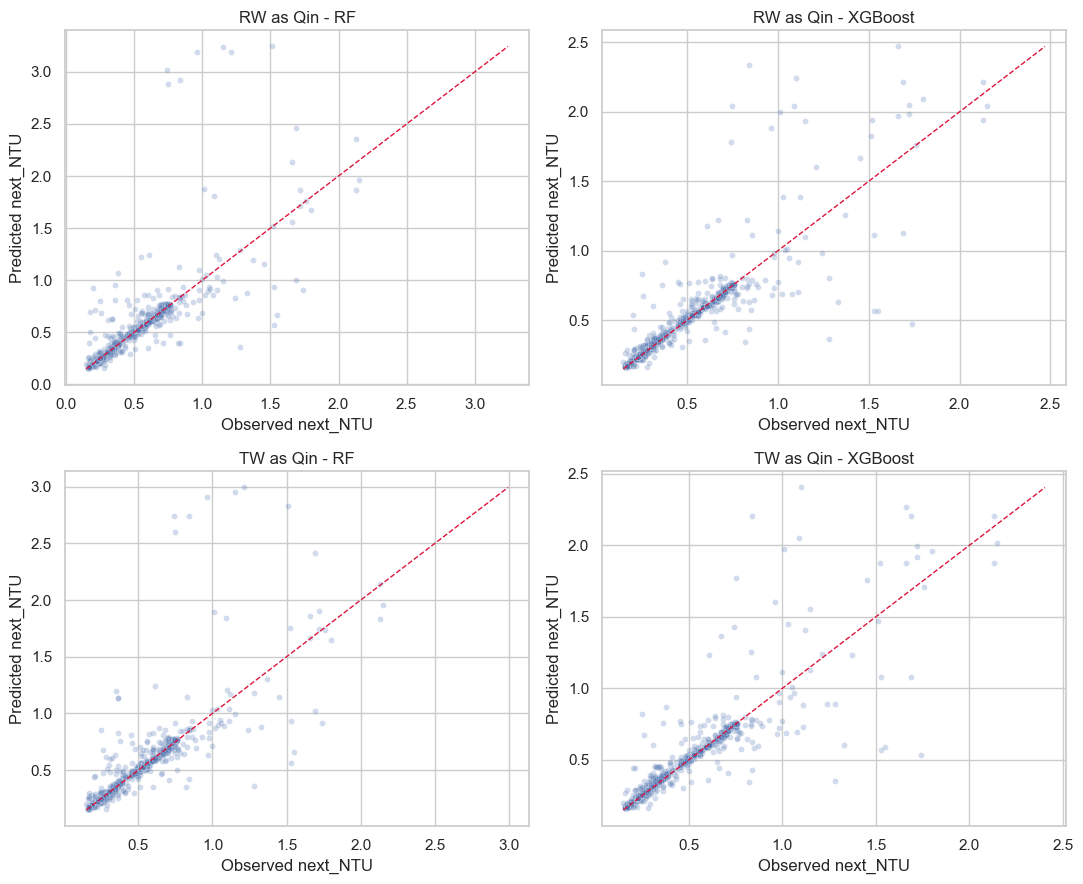

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False)
for ax, ((scenario, model_name), pred_df) in zip(axes.ravel(), predictions.items()):
    shown = pred_df.tail(500)
    ax.plot(shown["DATETIME"], shown["Observed next_NTU"], label="Observed", linewidth=1.4)
    ax.plot(shown["DATETIME"], shown["Predicted next_NTU"], label="Predicted", linewidth=1.1, alpha=0.85)
    ax.set_title(f"{scenario} - {model_name} (last 500 test samples)")
    ax.set_ylabel("NTU")
    ax.tick_params(axis="x", rotation=25)
    ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, ((scenario, model_name), pred_df) in zip(axes.ravel(), predictions.items()):
    sns.scatterplot(data=pred_df, x="Observed next_NTU", y="Predicted next_NTU", alpha=0.25, s=18, ax=ax)
    lo = min(pred_df["Observed next_NTU"].min(), pred_df["Predicted next_NTU"].min())
    hi = max(pred_df["Observed next_NTU"].max(), pred_df["Predicted next_NTU"].max())
    ax.plot([lo, hi], [lo, hi], "--", color="crimson", linewidth=1)
    ax.set_title(f"{scenario} - {model_name}")
plt.tight_layout()
plt.show()

## 7. 自动结论

In [7]:
model_metrics = metrics[metrics["模型"] != "持久性基线"].copy()
best_abs = model_metrics.loc[model_metrics["RMSE"].idxmin()]
best_delta = model_metrics.loc[model_metrics["ΔNTU Pearson r"].abs().idxmax()]
best_importance = importance_table.loc[importance_table["置换重要性（MSE 增量）"].idxmax()]

baseline_lookup = metrics[metrics["模型"] == "持久性基线"].set_index("Qin 方案")
baseline_rmse = baseline_lookup.loc[best_abs["Qin 方案"], "RMSE"]
improvement = (baseline_rmse - best_abs["RMSE"]) / baseline_rmse

display(Markdown(f"""
### 结果摘要

- 绝对 `next_NTU` 预测中，RMSE 最低的是 **{best_abs['Qin 方案']} + {best_abs['模型']}**：Pearson $r={best_abs['next_NTU Pearson r']:.3f}$，$R^2={best_abs['R²']:.3f}$，RMSE={best_abs['RMSE']:.4f}。
- 相对同一测试期的持久性基线，最佳模型 RMSE 改善 **{improvement:.1%}**。若改善很小，较高的 `next_NTU` 相关性主要来自 `current_NTU` 的自相关，而不是流量项。
- 对未来变化量 $\Delta NTU$，绝对 Pearson 相关性最高的是 **{best_delta['Qin 方案']} + {best_delta['模型']}**，$r={best_delta['ΔNTU Pearson r']:.3f}$，非零变化方向准确率={best_delta['非零变化方向准确率']:.1%}。这是判断公式分项是否捕捉动态信息的更关键指标。
- 测试集置换重要性最高的分项是 **{best_importance['特征']}**（{best_importance['Qin 方案']} + {best_importance['模型']}）。应结合完整重要性表判断入流项、出流项是否在不同模型中都具有稳定正贡献。

### 解释边界

树模型相关性只能说明这些代理分项具有预测信息，不能证明物料衡算参数已经被识别。液位不是体积，两个流量也未经过真实水力停留时间校准；若流量分项的重要性接近 0，则当前数据更支持“NTU 自身惯性”，而非现有代理下的即时物料衡算。
"""))


### 结果摘要

- 绝对 `next_NTU` 预测中，RMSE 最低的是 **TW as Qin + XGBoost**：Pearson $r=0.889$，$R^2=0.756$，RMSE=0.1382。
- 相对同一测试期的持久性基线，最佳模型 RMSE 改善 **-21.7%**。若改善很小，较高的 `next_NTU` 相关性主要来自 `current_NTU` 的自相关，而不是流量项。
- 对未来变化量 $\Delta NTU$，绝对 Pearson 相关性最高的是 **TW as Qin + RF**，$r=0.341$，非零变化方向准确率=53.8%。这是判断公式分项是否捕捉动态信息的更关键指标。
- 测试集置换重要性最高的分项是 **Inflow term (RW as Qin)**（RW as Qin + RF）。应结合完整重要性表判断入流项、出流项是否在不同模型中都具有稳定正贡献。

### 解释边界

树模型相关性只能说明这些代理分项具有预测信息，不能证明物料衡算参数已经被识别。液位不是体积，两个流量也未经过真实水力停留时间校准；若流量分项的重要性接近 0，则当前数据更支持“NTU 自身惯性”，而非现有代理下的即时物料衡算。
